# Does this frame deserve an API call?

Every vision call costs money and ~0.5s. Before paying, there is a free question:
**did anything actually change since the last frame we paid for?**

A camera answers "no" most of the time — and still hands you a *different* file every second,
because sensor grain, the IR illuminator switching on and JPEG re-encoding all move pixels
while nothing moves in the room.

So the gate has one job: **let real change through, swallow noise.** This notebook measures
four candidate gates on the actual footage and shows where each one breaks.

| what is compared | pairs that must be **skipped** | pairs that must be **sent** |
|---|---|---|
| same frame twice, + sensor noise, + brightness step, + JPEG recompression | 4 | 3 (the cat actually moves) |

Then two traps that matter more than the choice of metric:

1. comparing against the **previous** frame instead of the **last frame you paid for** — a slow event never fires;
2. no heartbeat — the gate can honestly say "nothing changed", never "the event did not happen".

**No API calls here.** Everything below is local and runs in milliseconds.

In [39]:
import base64
from io import BytesIO
from pathlib import Path
from time import perf_counter

from IPython.display import HTML, display
from PIL import Image, ImageChops, ImageFilter, ImageStat

DATA_DIR = Path("data") if Path("data").is_dir() else Path("../data")

API_SIZE = (640, 360)  # what a real request sends (see groq.ipynb)
GATE_SIZE = (128, 72)  # what the gate compares: 25x fewer pixels, and downscaling is a free low-pass filter
API_CALL_SECONDS = 0.47  # measured in groq.ipynb: one image request to qwen3.6-27b


def load(name: str, size=API_SIZE) -> Image.Image:
    """Camera PNG -> grayscale, fixed size.

    Fixed size, not aspect-preserving: these frames are 1996x1126 / 2004x1124 / 2002x1124,
    and every pixel-wise metric needs both images on the same grid.
    """
    return Image.open(DATA_DIR / name).convert("L").resize(size)


def small(image: Image.Image, size=GATE_SIZE) -> Image.Image:
    return image.resize(size)


FRAMES = ["1.png", "2.png", "3.png"]
frames = {name: load(name) for name in FRAMES}

print("source sizes:", {n: Image.open(DATA_DIR / n).size for n in FRAMES})
print("gate compares:", GATE_SIZE, "grayscale =", GATE_SIZE[0] * GATE_SIZE[1], "pixels")

source sizes: {'1.png': (1996, 1126), '2.png': (2004, 1124), '3.png': (2002, 1124)}
gate compares: (128, 72) grayscale = 9216 pixels


In [40]:
# Three ways a camera hands you a "new" frame while the room stands still.


def add_noise(image: Image.Image, sigma: int = 8) -> Image.Image:
    """Sensor grain — free with every frame, worse in the dark."""
    noise = Image.effect_noise(image.size, sigma)  # gaussian, centred on 128
    return ImageChops.add(image, noise, scale=1, offset=-128)


def brighten(image: Image.Image, delta: int = 20) -> Image.Image:
    """IR illuminator kicks in / auto-gain steps: every pixel shifts, nothing moves."""
    return image.point(lambda p: min(255, p + delta))


def recompress(image: Image.Image, quality: int = 40) -> Image.Image:
    """Same picture after another trip through the camera's JPEG encoder."""
    buffer = BytesIO()
    image.save(buffer, "JPEG", quality=quality)
    return Image.open(BytesIO(buffer.getvalue())).convert("L")


base = frames["1.png"]

# (label, frame A, frame B, did anything really change?, note)
PAIRS = [
    ("same frame twice", base, base, False, "camera idle"),
    ("+ sensor noise", base, add_noise(base), False, "grain only"),
    ("+ brightness step", base, brighten(base), False, "IR gain, +20 on every pixel"),
    ("+ JPEG recompression", base, recompress(base), False, "same picture, new bytes"),
    ("1.png -> 2.png", frames["1.png"], frames["2.png"], True, "cat moved on the chair"),
    ("1.png -> 3.png", frames["1.png"], frames["3.png"], True, "cat is on the table now"),
    ("2.png -> 3.png", frames["2.png"], frames["3.png"], True, "cat is on the table now"),
]

print(f"{sum(not c for *_, c, _ in PAIRS)} pairs must be skipped, {sum(c for *_, c, _ in PAIRS)} must be sent")

4 pairs must be skipped, 3 must be sent


In [41]:
# Four candidate gates, cheapest first. All return "how different", so bigger = more likely a real event.


def mean_abs_diff(a: Image.Image, b: Image.Image) -> float:
    """Average |pixel difference| over the whole frame, 0..255. The obvious one."""
    return ImageStat.Stat(ImageChops.difference(small(a), small(b))).mean[0]


def blurred_diff(a: Image.Image, b: Image.Image, radius: int = 2) -> float:
    """Same, after a blur: grain is high-frequency, a cat is not."""
    blur = ImageFilter.GaussianBlur(radius)
    return ImageStat.Stat(ImageChops.difference(small(a).filter(blur), small(b).filter(blur))).mean[0]


def dhash(image: Image.Image, size: int = 16) -> int:
    """Gradient hash: each bit answers "is this pixel brighter than its right neighbour".

    Bits are comparisons *inside* one frame, so adding 20 to every pixel changes nothing.
    size=16 -> 256 bits; the usual 8x8 is too coarse to notice a cat in a wide shot.
    """
    pixels = image.resize((size + 1, size), Image.LANCZOS).tobytes()  # grayscale -> one byte per pixel
    bits = 0
    for row in range(size):
        for col in range(size):
            left = pixels[row * (size + 1) + col]
            right = pixels[row * (size + 1) + col + 1]
            bits = bits << 1 | (left > right)
    return bits


def hash_distance(a: Image.Image, b: Image.Image) -> float:
    """Hamming distance between the two hashes: 0 = same picture, ~128 = unrelated."""
    return float(bin(dhash(a) ^ dhash(b)).count("1"))


def prepared(a: Image.Image, b: Image.Image, radius: int = 2) -> tuple:
    """Downscale, blur away grain, and pull b to a's brightness."""
    blur = ImageFilter.GaussianBlur(radius)
    first, second = small(a).filter(blur), small(b).filter(blur)
    shift = ImageStat.Stat(second).mean[0] - ImageStat.Stat(first).mean[0]
    return first, second.point(lambda p: max(0, min(255, p - shift)))


def levelled_difference(a: Image.Image, b: Image.Image, radius: int = 2) -> Image.Image:
    """What the tile metric looks at: blurred, brightness-matched difference."""
    return ImageChops.difference(*prepared(a, b, radius))


def tiles_of(difference: Image.Image, grid: int = 8) -> list:
    """Chop a difference image into a grid x grid board: average change per tile."""
    width, height = difference.size
    return [
        [
            ImageStat.Stat(difference.crop((x * width // grid, y * height // grid,
                                            (x + 1) * width // grid, (y + 1) * height // grid))).mean[0]
            for x in range(grid)
        ]
        for y in range(grid)
    ]


def tile_scores(a: Image.Image, b: Image.Image, grid: int = 8) -> list:
    return tiles_of(levelled_difference(a, b), grid)


def tile_max_diff(a: Image.Image, b: Image.Image, grid: int = 8) -> float:
    """The *worst tile* instead of the frame average.

    A cat is a few percent of a wide frame, so an average buries it in noise;
    the tile it walks through does not.
    """
    return max(max(row) for row in tile_scores(a, b, grid))


METRICS = [
    ("mean abs diff", mean_abs_diff, "grey levels"),
    ("blurred diff", blurred_diff, "grey levels"),
    ("dhash hamming", hash_distance, "bits of 256"),
    ("tile max diff", tile_max_diff, "grey levels"),
]

# self-check: identical input must score zero, and a moved cat must beat a brightness step
for _, metric, _ in METRICS:
    assert metric(base, base) == 0, metric.__name__
assert hash_distance(base, brighten(base)) == 0, "a gradient hash must ignore a global brightness shift"
assert tile_max_diff(base, frames["3.png"]) > tile_max_diff(base, brighten(base))
print("metrics ok")

metrics ok


,frame B,raw difference x8,+ blur + brightness match,tiles
+ brightness step,,,,
1.png -> 3.png,,,,

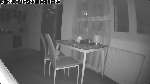
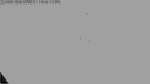
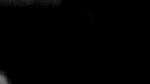
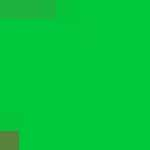
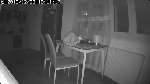
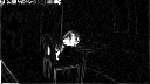
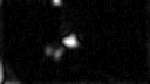
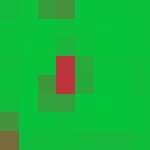

In [42]:
# Display helpers — the point of this notebook is to *see* what the numbers are made of.

THUMB_WIDTH = 150
AMPLIFY = 8  # a real difference is a handful of grey levels; multiply it or you see a black rectangle


def thumb(image: Image.Image, width: int = THUMB_WIDTH, quality: int = 60) -> str:
    resized = image.resize((width, round(image.height * width / image.width)), Image.NEAREST)
    buffer = BytesIO()
    resized.convert("RGB").save(buffer, "JPEG", quality=quality)
    return f'<img src="data:image/jpeg;base64,{base64.b64encode(buffer.getvalue()).decode()}" width="{width}">'


def loud(difference: Image.Image, factor: int = AMPLIFY) -> str:
    return thumb(difference.point(lambda p: min(255, p * factor)))


def raw_difference_view(a: Image.Image, b: Image.Image) -> str:
    """Straight |a - b|: a light change lights up the whole frame."""
    return loud(ImageChops.difference(small(a), small(b)))


def difference_view(a: Image.Image, b: Image.Image) -> str:
    """After blur + brightness matching: grain and lamps gone, movement left."""
    return loud(levelled_difference(a, b))


def heat(fraction: float) -> tuple:
    fraction = max(0.0, min(1.0, fraction))
    return (round(255 * fraction), round(200 * (1 - fraction)), 60)  # green = quiet, red = loud


TILE_SCALE = 12  # one colour scale for every board in the notebook: green 0 -> red 12+.
# ponytail: per-board auto-scaling looked prettier and lied — a quiet board went as red as a loud one.


def board_view(board: list, scale: float = None) -> str:
    """The grid the tile metric maxes over. One red square = one place where something moved."""
    grid = len(board)
    top = scale or TILE_SCALE
    image = Image.new("RGB", (grid, grid))
    image.putdata([heat(value / top) for row in board for value in row])
    return thumb(image)


def tile_view(a: Image.Image, b: Image.Image, scale: float = None) -> str:
    return board_view(tile_scores(a, b), scale)


def bar(value: float, top: float, colour: str) -> str:
    width = max(2, round(110 * value / top)) if top else 2
    return f"<div style='background:{colour};width:{width}px;height:9px;border-radius:2px'></div>"


legend = ""
for label, a, b, _, _ in PAIRS:
    if label in ("+ brightness step", "1.png -> 3.png"):
        legend += (
            f"<tr><td style='padding:6px'><b>{label}</b></td>"
            f"<td style='padding:6px'>{thumb(b)}</td>"
            f"<td style='padding:6px'>{raw_difference_view(a, b)}</td>"
            f"<td style='padding:6px'>{difference_view(a, b)}</td>"
            f"<td style='padding:6px'>{tile_view(a, b)}</td></tr>"
        )
display(HTML(
    "<p>the pipeline, on the pair that must be skipped and the pair that must be sent:</p>"
    "<table style='border-collapse:collapse'><tr><th></th><th>frame B</th>"
    f"<th>raw difference x{AMPLIFY}</th><th>+ blur + brightness match</th><th>tiles</th></tr>"
    f"{legend}</table>"
    "<p>the brightness step fills the raw column and empties the next one; the cat survives both "
    "as one blob and one red tile. That gap is what the numbers below measure.<br>"
    f"<span style='color:#888'>every board in this notebook uses the same colour scale: "
    f"green = 0, red = {TILE_SCALE}+ grey levels of change in that tile.</span></p>"
))

pair,frame B,difference x8,tiles,mean abs diffgrey levels2.2 ms/pair,blurred diffgrey levels2.5 ms/pair,dhash hammingbits of 2562.4 ms/pair,tile max diffgrey levels6.2 ms/pair
same frame twicecamera idleSKIP expected,,,,0.00,0.00,0.00,0.00
+ sensor noisegrain onlySKIP expected,,,,1.13,0.56,5.00,1.15
"+ brightness stepIR gain, +20 on every pixelSKIP expected",,,,19.86,19.86,0.00,4.19
"+ JPEG recompressionsame picture, new bytesSKIP expected",,,,0.65,0.28,3.00,0.80
1.png -> 2.pngcat moved on the chairSEND expected,,,,2.01,1.19,13.00,17.03
1.png -> 3.pngcat is on the table nowSEND expected,,,,2.03,1.07,6.00,8.94
2.png -> 3.pngcat is on the table nowSEND expected,,,,2.57,1.39,9.00,19.12

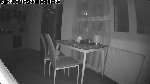
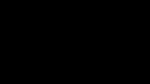
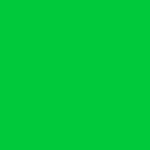
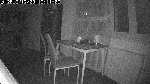
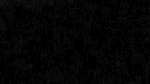
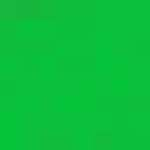
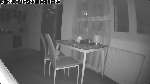
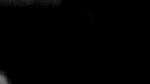
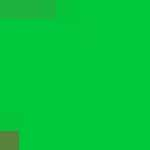
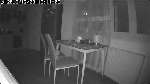
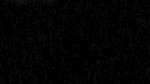
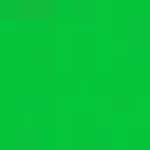
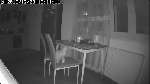
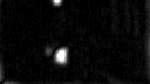
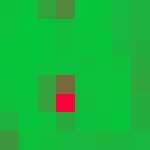
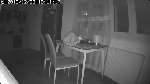
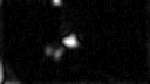
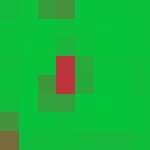
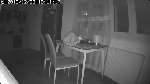
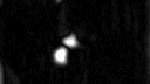
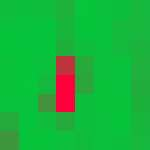

In [43]:
# Every pair, seen and measured. Read the "difference" column first, the numbers second.
# Grey bar = should be skipped, orange bar = should be sent.

scores, cost_ms = {}, {}
for name, metric, _ in METRICS:
    started = perf_counter()
    scores[name] = {label: metric(a, b) for label, a, b, _, _ in PAIRS}
    cost_ms[name] = (perf_counter() - started) / len(PAIRS) * 1000

header = "".join(
    f"<th style='padding:6px'>{name}<br><span style='color:#888;font-weight:normal'>{unit}<br>"
    f"{cost_ms[name]:.1f} ms/pair</span></th>"
    for name, _, unit in METRICS
)
rows = ""
for label, a, b, changed, note in PAIRS:
    colour = "#e67e22" if changed else "#999"
    cells = ""
    for name, _, _ in METRICS:
        top = max(scores[name].values())
        cells += (f"<td style='padding:6px'>{bar(scores[name][label], top, colour)}"
                  f"<span style='color:#555'>{scores[name][label]:.2f}</span></td>")
    rows += (
        f"<tr style='border-top:1px solid #ddd'>"
        f"<td style='padding:6px'><b>{label}</b><br><span style='color:#888'>{note}</span><br>"
        f"<span style='color:{colour}'>{'SEND expected' if changed else 'SKIP expected'}</span></td>"
        f"<td style='padding:6px'>{thumb(b)}</td>"
        f"<td style='padding:6px'>{difference_view(a, b)}</td>"
        f"<td style='padding:6px'>{tile_view(a, b)}</td>"
        f"{cells}</tr>"
    )

display(HTML(
    "<table style='border-collapse:collapse'><tr>"
    "<th align='left' style='padding:6px'>pair</th>"
    "<th align='left' style='padding:6px'>frame B</th>"
    f"<th align='left' style='padding:6px'>difference x{AMPLIFY}</th>"
    "<th align='left' style='padding:6px'>tiles</th>"
    f"{header}</tr>{rows}</table>"
    "<p>the brightness row is the interesting one: nothing moved, and the first two columns "
    "score it louder than a cat climbing onto a table.<br>"
    f"one API call: <b>{API_CALL_SECONDS}s</b> and ~900 prompt tokens · "
    f"cheapest gate above: <b>{min(cost_ms.values()):.1f} ms</b>, dearest: "
    f"<b>{max(cost_ms.values()):.1f} ms</b> — still "
    f"{API_CALL_SECONDS * 1000 / max(cost_ms.values()):.0f}x cheaper than asking</p>"
))

## Where is the threshold?

A gate is only usable if the **loudest thing that must be skipped** scores lower than the
**quietest thing that must be sent**. That gap is the whole story — pick the metric with the
widest one, put the threshold in the middle, and note *which* quiet pair sets the floor:
that pair is what will wake your camera at 3am for nothing.

In [44]:
summary = {}
for name, _, _ in METRICS:
    quiet = max(((scores[name][label], label) for label, _, _, changed, _ in PAIRS if not changed))
    signal = min(((scores[name][label], label) for label, _, _, changed, _ in PAIRS if changed))
    summary[name] = {
        "floor": quiet[0], "floor_pair": quiet[1],
        "signal": signal[0], "signal_pair": signal[1],
        "gap": signal[0] / quiet[0] if quiet[0] else float("inf"),
        "threshold": (quiet[0] + signal[0]) / 2,
    }

rows = ""
for name, _, unit in METRICS:
    s = summary[name]
    usable = s["gap"] > 1
    rows += (
        f"<tr><td style='padding:6px'><b>{name}</b> <span style='color:#888'>({unit})</span></td>"
        f"<td style='padding:6px'>{s['floor']:.2f}<br><span style='color:#888'>{s['floor_pair']}</span></td>"
        f"<td style='padding:6px'>{s['signal']:.2f}<br><span style='color:#888'>{s['signal_pair']}</span></td>"
        f"<td style='padding:6px;color:{'#2e7d32' if usable else '#c62828'}'><b>{s['gap']:.2f}x</b></td>"
        f"<td style='padding:6px'>{('threshold ' + format(s['threshold'], '.1f')) if usable else 'not separable'}</td></tr>"
    )
display(HTML(
    "<table style='border-collapse:collapse'><tr><th align='left'>metric</th>"
    "<th align='left'>loudest skip</th><th align='left'>quietest send</th>"
    "<th align='left'>gap</th><th align='left'>verdict</th></tr>" + rows + "</table>"
))

# The winner, and the check that it is one: the brightness step must not outscore a moving cat.
GATE, GATE_NAME = tile_max_diff, "tile max diff"
THRESHOLD = round(summary[GATE_NAME]["threshold"], 1)
assert summary[GATE_NAME]["gap"] > 1.5, "tile metric must clearly separate noise from real change"
assert summary["mean abs diff"]["gap"] < 1, "whole-frame average is expected to fail on the lamp"

decisions = "".join(
    f"<tr><td style='padding:6px'>{label}</td>"
    f"<td style='padding:6px'>{scores[GATE_NAME][label]:.2f}</td>"
    f"<td style='padding:6px'><b>{'SEND' if (scores[GATE_NAME][label] > THRESHOLD) else 'skip'}</b></td>"
    f"<td style='padding:6px;color:{'#2e7d32' if (scores[GATE_NAME][label] > THRESHOLD) == changed else '#c62828'}'>"
    f"{'✓' if (scores[GATE_NAME][label] > THRESHOLD) == changed else '✗'}</td></tr>"
    for label, _, _, changed, _ in PAIRS
)
saved = sum((scores[GATE_NAME][label] <= THRESHOLD) for label, *_ in PAIRS)
display(HTML(
    f"<h4>{GATE_NAME} at threshold {THRESHOLD}</h4>"
    f"<table style='border-collapse:collapse'>{decisions}</table>"
    f"<p>{saved}/{len(PAIRS)} pairs never reach the API: "
    f"<b>{saved * API_CALL_SECONDS:.1f}s</b> and ~{saved * 900} prompt tokens not spent</p>"
))

metric,loudest skip,quietest send,gap,verdict
mean abs diff (grey levels),19.86+ brightness step,2.011.png -> 2.png,0.10x,not separable
blurred diff (grey levels),19.86+ brightness step,1.071.png -> 3.png,0.05x,not separable
dhash hamming (bits of 256),5.00+ sensor noise,6.001.png -> 3.png,1.20x,threshold 5.5
tile max diff (grey levels),4.19+ brightness step,8.941.png -> 3.png,2.13x,threshold 6.6


same frame twice,0.00,skip,✓
+ sensor noise,1.15,skip,✓
+ brightness step,4.19,skip,✓
+ JPEG recompression,0.80,skip,✓
1.png -> 2.png,17.03,SEND,✓
1.png -> 3.png,8.94,SEND,✓
2.png -> 3.png,19.12,SEND,✓


## The trap: compare against *what*?

The obvious loop is "compare this frame to the previous one". It silently loses every slow
event — a cat creeping onto the table over ten seconds, a washing machine winding down, a
child waking up. Each single step is below the threshold, so the gate is happy, forever.

Fix: keep an **anchor** — the last frame you actually paid for — and compare against that.
Drift accumulates against a fixed anchor, so a slow event eventually crosses the line.

Below: the same change spread over 10 frames, measured both ways.


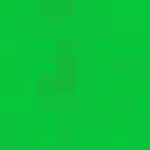
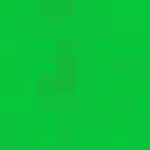
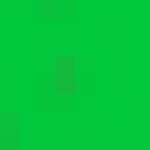
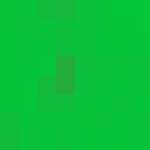
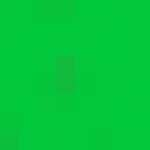
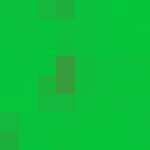
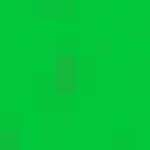
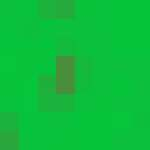
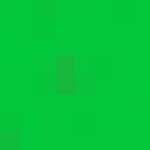
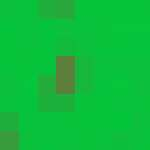
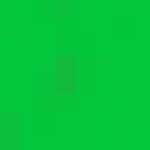
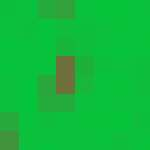
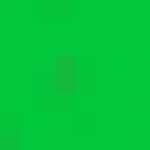
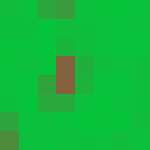
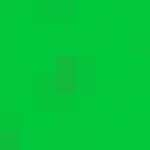
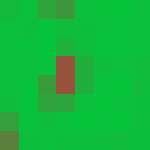
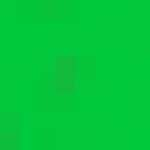
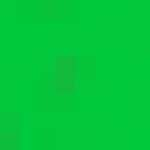
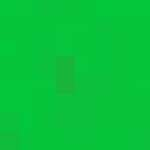
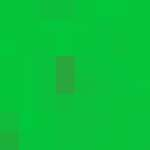

In [45]:
# A slow event, faked by crossfading 1.png into 3.png over 10 frames.
# ponytail: a crossfade is not real motion, it is the cheapest thing with the right shape —
# small per-frame change, large total change.
STEPS = 10
CREEP = [Image.blend(frames["1.png"], frames["3.png"], i / STEPS) for i in range(STEPS + 1)]
SCALE = 12  # fixed colour scale, so the tile boards below are comparable across steps

previous = anchor = CREEP[0]
naive, calls = [], 0
rows = ""
for index, frame in enumerate(CREEP[1:], 1):
    against_previous, against_anchor = GATE(previous, frame), GATE(anchor, frame)
    fired = against_anchor > THRESHOLD
    naive.append(against_previous)
    rows += (
        f"<tr style='border-top:1px solid #eee'><td style='padding:4px'>frame {index}</td>"
        f"<td style='padding:4px'>{tile_view(previous, frame, scale=SCALE)}</td>"
        f"<td style='padding:4px'>{bar(against_previous, SCALE, '#999')}"
        f"<span style='color:#555'>{against_previous:.2f}</span></td>"
        f"<td style='padding:4px'>{tile_view(anchor, frame, scale=SCALE)}</td>"
        f"<td style='padding:4px'>{bar(against_anchor, SCALE, '#e67e22')}"
        f"<span style='color:#555'>{against_anchor:.2f}</span></td>"
        f"<td style='padding:4px;color:#2e7d32'><b>{'API CALL' if fired else ''}</b></td></tr>"
    )
    previous = frame
    if fired:
        anchor, calls = frame, calls + 1

assert max(naive) < THRESHOLD, "vs-previous is supposed to sleep through the whole event"
assert calls >= 1, "vs-anchor is supposed to notice it"

display(HTML(
    "<table style='border-collapse:collapse'><tr><th></th>"
    "<th colspan='2' style='padding:4px'>vs previous frame</th>"
    "<th colspan='2' style='padding:4px'>vs anchor (last frame we paid for)</th><th></th></tr>"
    + rows + "</table>"
    f"<p>same colour scale on both sides. Left stays green all the way down: threshold {THRESHOLD}, "
    f"and vs-previous peaks at <b>{max(naive):.2f}</b> — the event is missed completely.<br>"
    f"Right goes red as drift piles up against a fixed anchor and fires <b>{calls}x</b> "
    f"over {STEPS} frames: {STEPS - calls} calls skipped, event still caught "
    f"(the board turns green again right after — the anchor moved).</p>"
))

## What this gate can and cannot say

It can say **"nothing changed"**. It can never say **"the event did not happen"** — it does not
know what the event is. So the gate decides *when* to ask the model, never *what the answer is*.

The pipeline that survived every pair here, in order, a few ms in total:

1. downscale to 128x72 grayscale (a free low-pass filter),
2. blur — kills sensor grain,
3. match the mean brightness — kills lamps, IR gain, auto-exposure,
4. take the loudest tile of an 8x8 board, not the frame average — a cat is a few percent of a wide shot.

Two more rules once frames arrive as a stream:

- **heartbeat** — send one frame every N minutes no matter what the gate says, so a stuck
  gate or a threshold set too high cannot hide an event forever;
- **cooldown** — after a call fires, stay quiet for a few seconds; motion comes in bursts and
  every frame of the burst says the same thing.

Calibrate on real footage, not on numbers from a paper. Two things this footage already shows:
the floor is set by the **brightness step** (a global +20 that clipping makes uneven), and the
**timestamp burnt into the top-left corner changes every single frame** — visible as a white
streak in the raw-difference column. Here the blur erases it; on a camera with a bigger overlay
you mask that rectangle out instead. On your camera it will be headlights, a swaying branch, or
the IR cut filter clacking over.

Known ceilings, left in place on purpose. A camera that gets **bumped** shifts every pixel at
once and blows past any threshold here; undoing the shift before measuring costs ~11 ms
(try every offset in a small window, keep the best) — worth adding only if the camera actually
moves. **SSIM** is skipped (needs `scikit-image`, and on noisy IR the local windows fill with
grain), and so is **MOG2 background subtraction** (needs `opencv` and a *stream* to learn a
background model — the right answer for a swaying tree, pointless on stills).